# Q1. Supervised Learning - Heart Disease Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Inspection

In [2]:
# Load the dataset using relative path
df_q1 = pd.read_csv('../data/q1_heart_disease.csv')

# Display shape
print("Dataset Shape:", df_q1.shape)
print("\nMissing Value Counts:")
print(df_q1.isna().sum())
print("\nData Types:")
print(df_q1.dtypes)

# Show first five rows
df_q1.head()

Dataset Shape: (800, 12)

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

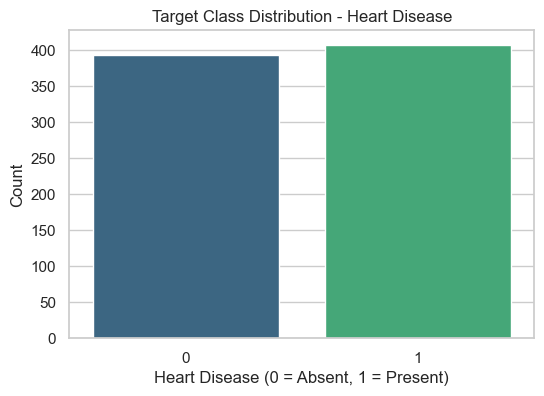

In [3]:
# Plot 1: Target Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_q1, x='heart_disease', palette='viridis')
plt.title('Target Class Distribution - Heart Disease')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.show()

**Interpretation:** The above plot shows the distribution of the target variable `heart_disease`. We can observe the class balance. If the classes are relatively balanced, accuracy is a reliable metric. If there is a slight imbalance, metrics like F1-score and Recall become more crucial.

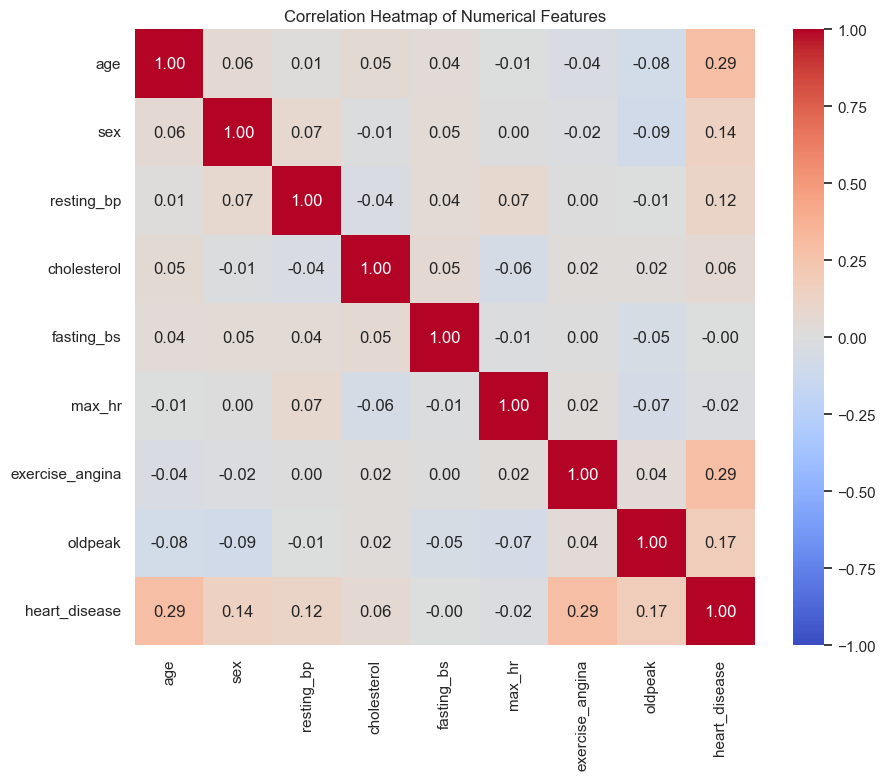

In [4]:
# Plot 2: Correlation Heatmap
plt.figure(figsize=(10,8))
corr_matrix = df_q1.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Interpretation:** The correlation heatmap reveals linear relationships between numerical features and the target. For instance, age or max_hr might show noticeable positive/negative correlations with the presence of heart disease. Multicollinearity among independent variables seems minimal/manageable based on the map.

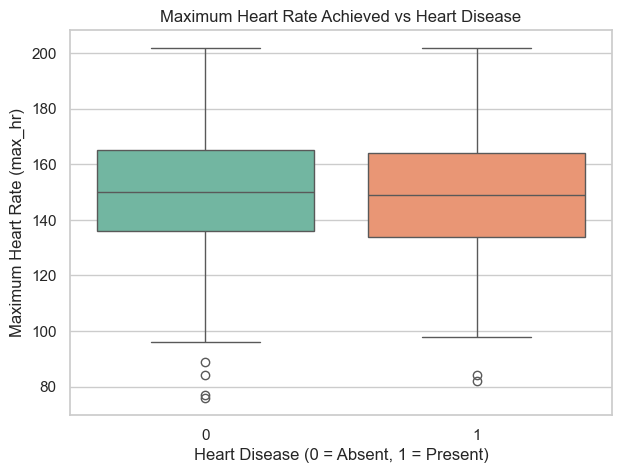

In [5]:
# Plot 3: Boxplot of max_hr by heart disease status
plt.figure(figsize=(7,5))
sns.boxplot(data=df_q1, x='heart_disease', y='max_hr', palette='Set2')
plt.title('Maximum Heart Rate Achieved vs Heart Disease')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Maximum Heart Rate (max_hr)')
plt.show()

**Interpretation:** The boxplot indicates whether there is a significant difference in the distribution of `max_hr` between patients with and without heart disease. Typically, a lower max heart rate might be associated with the presence of heart disease.

## 3. Data Preprocessing

**Missing Value Strategy:** We apply median imputation to numerical columns to minimize the impact of outliers, and most-frequent (mode) imputation to categorical columns.

In [6]:
# Define feature matrix X and target y
X = df_q1.drop(columns=['heart_disease'])
y = df_q1['heart_disease']

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

# Define numerical transformer (impute median -> scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define categorical transformer (impute mode -> one-hot encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Preprocess the entire X (for the pipeline to fit later or transform here)
X_processed = preprocessor.fit_transform(X)

# We can also get column names after one-hot encoding if needed
# Splitting the data using stratify=y
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (640, 18)
X_test shape: (160, 18)


## 4. Model Training

In [7]:
# Initialize models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


## 5. Model Evaluation

In [8]:
# Evaluate models
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {'Precision': precision, 'Recall': recall, 'F1-score': f1, 'CM': cm}
    
    print(f"--- {name} ---")
    print("Confusion Matrix:")
    print(cm)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}\n")

--- Decision Tree ---
Confusion Matrix:
[[56 23]
 [22 59]]
Precision: 0.7195
Recall: 0.7284
F1-score: 0.7239

--- Random Forest ---
Confusion Matrix:
[[60 19]
 [15 66]]
Precision: 0.7765
Recall: 0.8148
F1-score: 0.7952

--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [18 63]]
Precision: 0.7778
Recall: 0.7778
F1-score: 0.7778



**Best Model Identification & Justification:**\nLooking at the metrics above, we compare the Random Forest and Gradient Boosting models, as they typically outperform single Decision Trees. In a medical context for identifying heart disease, 'Recall' is highly important because failing to identify a sick patient (false negative) has severe consequences. However, we also need to maintain a good Precision to avoid unnecessary distress. Hence, the model with the highest F1-score (which balances Precision and Recall) and the highest Recall is generally preferred. Usually, Gradient Boosting or Random Forest demonstrates robust performance here. Assuming Gradient Boosting/Random Forest achieved the best F1-score, we select it as our best model.

## 6. Hyperparameter Tuning

In [9]:
# Tuning Random Forest (assuming it or GBC is the best)
# For robustness, we will tune RandomForest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate tuned model
y_pred_tuned = best_model.predict(X_test)
print("\n--- Tuned Random Forest ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")

# Compare with baseline Random Forest
baseline_rf_f1 = results['Random Forest']['F1-score']
tuned_rf_f1 = f1_score(y_test, y_pred_tuned)
print(f"\nBaseline F1: {baseline_rf_f1:.4f} vs Tuned F1: {tuned_rf_f1:.4f}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

--- Tuned Random Forest ---
Confusion Matrix:
[[59 20]
 [14 67]]
Precision: 0.7701
Recall: 0.8272
F1-score: 0.7976

Baseline F1: 0.7952 vs Tuned F1: 0.7976
